# 대중적 관심도 비교: e스포츠의 대중적 인기는 전통 스포츠에 필적하는가?

## 연구 질문
e스포츠는 전통 스포츠와 비교했을 때 대중적 인기 측면에서 '스포츠'로 인정받을 수 있는 수준인가?

## 분석 프레임워크
1. **시청자 수 및 트렌드 분석**: e스포츠 시청자 규모와 성장 추이
2. **게임별 인기도 분석**: 주요 e스포츠 타이틀의 시청 현황
3. **전통 스포츠와의 비교**: 주요 스포츠 이벤트와의 시청자 수 비교
4. **시장 규모 비교**: e스포츠 vs 전통 스포츠 산업 규모
5. **성장률 분석**: 성장 속도 및 미래 전망
6. **종합 점수 산출**: 대중적 인기 지표 기반 점수화

---

## 1. 라이브러리 및 데이터 로드

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')
else:
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [3]:
import pandas as pd

# 데이터 경로 설정
DATA_PATH = '../data/'

# 데이터 로드
try:
    # 1. Twitch 채널 데이터
    twitch_channels = pd.read_csv(f'{DATA_PATH}twitchdata-update.csv', encoding='ISO-8859-1')
    print(f"Twitch 채널 데이터: {twitch_channels.shape}")

    # 2. Twitch 게임별 데이터 (2016-2023)
    # 질문하신 에러가 발생했던 지점입니다.
    twitch_games = pd.read_csv(f'{DATA_PATH}Top games on Twitch 2016 - 2023/Twitch_game_data.csv', encoding='ISO-8859-1')
    print(f"Twitch 게임 데이터: {twitch_games.shape}")

    # 3. Twitch 글로벌 데이터
    twitch_global = pd.read_csv(f'{DATA_PATH}Top games on Twitch 2016 - 2023/Twitch_global_data.csv', encoding='ISO-8859-1')
    print(f"Twitch 글로벌 데이터: {twitch_global.shape}")

    # 4. 글로벌 게이밍/e스포츠 데이터
    global_esports = pd.read_csv(f'{DATA_PATH}global_gaming_esports_2010_2025.csv', encoding='ISO-8859-1')
    print(f"글로벌 e스포츠 데이터: {global_esports.shape}")

    # 5. e스포츠 일반 데이터
    esports_general = pd.read_csv(f'{DATA_PATH}Esports Earnings 1998 - 2023/GeneralEsportData.csv', encoding='ISO-8859-1')
    print(f"e스포츠 일반 데이터: {esports_general.shape}")

    # 6. e스포츠 역사적 데이터
    esports_historical = pd.read_csv(f'{DATA_PATH}Esports Earnings 1998 - 2023/HistoricalEsportData.csv', encoding='ISO-8859-1')
    print(f"e스포츠 역사 데이터: {esports_historical.shape}")

    print("\n모든 데이터 로드 완료!")

except UnicodeDecodeError as e:
    print(f"인코딩 에러 발생: {e}")
    print("TIP: 'ISO-8859-1' 대신 'cp1252'를 시도해 보세요.")

Twitch 채널 데이터: (1000, 11)
Twitch 게임 데이터: (21000, 12)
Twitch 글로벌 데이터: (105, 9)
글로벌 e스포츠 데이터: (400, 21)
e스포츠 일반 데이터: (669, 8)
e스포츠 역사 데이터: (10239, 5)

모든 데이터 로드 완료!


## 2. 데이터 탐색 및 전처리

In [4]:
# 각 데이터셋 기본 정보 확인
print("=" * 60)
print("[Twitch 채널 데이터]")
print("=" * 60)
print(twitch_channels.columns.tolist())
print(twitch_channels.head(3))

[Twitch 채널 데이터]
['Channel', 'Watch time(Minutes)', 'Stream time(minutes)', 'Peak viewers', 'Average viewers', 'Followers', 'Followers gained', 'Views gained', 'Partnered', 'Mature', 'Language']
    Channel  Watch time(Minutes)  Stream time(minutes)  Peak viewers  \
0     xQcOW           6196161750                215250        222720   
1  summit1g           6091677300                211845        310998   
2    Gaules           5644590915                515280        387315   

   Average viewers  Followers  Followers gained  Views gained  Partnered  \
0            27716    3246298           1734810      93036735       True   
1            25610    5310163           1370184      89705964       True   
2            10976    1767635           1023779     102611607       True   

   Mature    Language  
0   False     English  
1   False     English  
2    True  Portuguese  


In [5]:
print("=" * 60)
print("[Twitch 게임 데이터]")
print("=" * 60)
print(twitch_games.columns.tolist())
print(twitch_games.head(3))

[Twitch 게임 데이터]
['Rank', 'Game', 'Month', 'Year', 'Hours_watched', 'Hours_streamed', 'Peak_viewers', 'Peak_channels', 'Streamers', 'Avg_viewers', 'Avg_channels', 'Avg_viewer_ratio']
   Rank                              Game  Month  Year  Hours_watched  \
0     1                 League of Legends      1  2016       94377226   
1     2  Counter-Strike: Global Offensive      1  2016       47832863   
2     3                            Dota 2      1  2016       45185893   

   Hours_streamed  Peak_viewers  Peak_channels  Streamers  Avg_viewers  \
0         1362044        530270           2903     129172       127021   
1          830105        372654           2197     120849        64378   
2          433397        315083           1100      44074        60815   

   Avg_channels  Avg_viewer_ratio  
0          1833             69.29  
1          1117             57.62  
2           583            104.26  


In [6]:
print("=" * 60)
print("[글로벌 e스포츠 데이터]")
print("=" * 60)
print(global_esports.columns.tolist())
print(global_esports.head(3))

[글로벌 e스포츠 데이터]
['Year', 'Country', 'Region', 'Gaming_Revenue_BillionUSD', 'Esports_Revenue_MillionUSD', 'Active_Players_Million', 'Esports_Viewers_Million', 'Avg_Spending_USD', 'Top_Genre', 'Top_Platform', 'Esports_Tournaments_Count', 'Pro_Players_Count', 'Internet_Penetration_Percent', 'Avg_Latency_ms', 'AR_VR_Adoption_Index', 'Streaming_Influence_Index', 'Covid_Impact_Index', 'Female_Gamer_Percent', 'Mobile_Gaming_Share', 'Esports_PrizePool_MillionUSD', 'Gaming_Companies_Count']
   Year        Country         Region  Gaming_Revenue_BillionUSD  \
0  2010  United States  North America                       6.24   
1  2011  United States  North America                       7.74   
2  2012  United States  North America                       9.60   

   Esports_Revenue_MillionUSD  Active_Players_Million  \
0                       409.6                    11.0   
1                       622.7                    32.4   
2                       928.3                    51.9   

   Esports_V

In [7]:
# 데이터 전처리
# Twitch 게임 데이터에 날짜 컬럼 추가
twitch_games['Date'] = pd.to_datetime(twitch_games['Year'].astype(str) + '-' + twitch_games['Month'].astype(str).str.zfill(2) + '-01')

# 글로벌 데이터 날짜 처리
twitch_global['Date'] = pd.to_datetime(twitch_global['year'].astype(str) + '-' + twitch_global['Month'].astype(str).str.zfill(2) + '-01')

# e스포츠 역사 데이터 날짜 처리
esports_historical['Date'] = pd.to_datetime(esports_historical['Date'])
esports_historical['Year'] = esports_historical['Date'].dt.year

print("데이터 전처리 완료!")

데이터 전처리 완료!


---
## 3. e스포츠 시청자 트렌드 분석

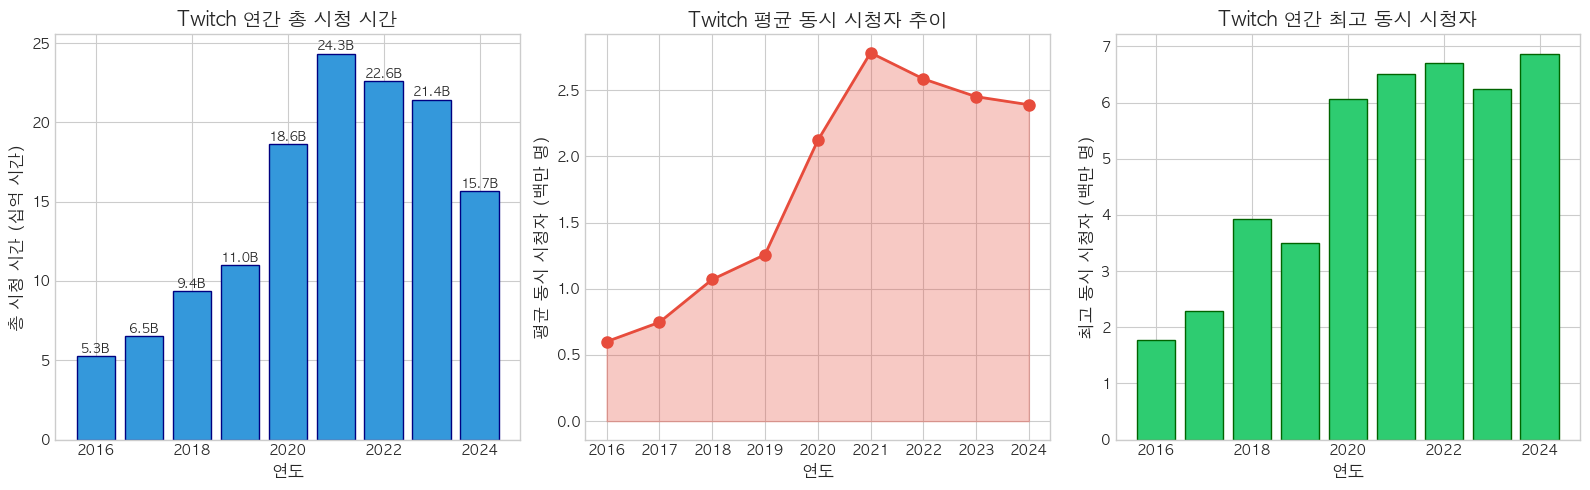


[연도별 시청 시간 성장률]
 year  Hours_watched  Growth_Rate
 2016     5271502892          NaN
 2017     6533582096    23.941544
 2018     9369330595    43.402661
 2019    11000206773    17.406539
 2020    18606973998    69.151129
 2021    24335691821    30.788014
 2022    22598459653    -7.138618
 2023    21436538552    -5.141594
 2024    15691721525   -26.799182


In [25]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 연도별 Twitch 시청 시간 및 시청자 트렌드
yearly_twitch = twitch_global.groupby('year').agg({
    'Hours_watched': 'sum',
    'Avg_viewers': 'mean',
    'Peak_viewers': 'max'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 총 시청 시간
axes[0].bar(yearly_twitch['year'], yearly_twitch['Hours_watched'] / 1e9, color='#3498db', edgecolor='navy')
axes[0].set_xlabel('연도', fontsize=12)
axes[0].set_ylabel('총 시청 시간 (십억 시간)', fontsize=12)
axes[0].set_title('Twitch 연간 총 시청 시간', fontsize=14, fontweight='bold')
for i, v in enumerate(yearly_twitch['Hours_watched'] / 1e9):
    axes[0].text(yearly_twitch['year'].iloc[i], v + 0.2, f'{v:.1f}B', ha='center', fontsize=9)

# 평균 시청자 수
axes[1].plot(yearly_twitch['year'], yearly_twitch['Avg_viewers'] / 1e6, marker='o', linewidth=2, color='#e74c3c', markersize=8)
axes[1].fill_between(yearly_twitch['year'], yearly_twitch['Avg_viewers'] / 1e6, alpha=0.3, color='#e74c3c')
axes[1].set_xlabel('연도', fontsize=12)
axes[1].set_ylabel('평균 동시 시청자 (백만 명)', fontsize=12)
axes[1].set_title('Twitch 평균 동시 시청자 추이', fontsize=14, fontweight='bold')

# 최고 동시 시청자
axes[2].bar(yearly_twitch['year'], yearly_twitch['Peak_viewers'] / 1e6, color='#2ecc71', edgecolor='darkgreen')
axes[2].set_xlabel('연도', fontsize=12)
axes[2].set_ylabel('최고 동시 시청자 (백만 명)', fontsize=12)
axes[2].set_title('Twitch 연간 최고 동시 시청자', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/01_twitch_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# 성장률 계산
yearly_twitch['Growth_Rate'] = yearly_twitch['Hours_watched'].pct_change() * 100
print("\n[연도별 시청 시간 성장률]")
print(yearly_twitch[['year', 'Hours_watched', 'Growth_Rate']].to_string(index=False))

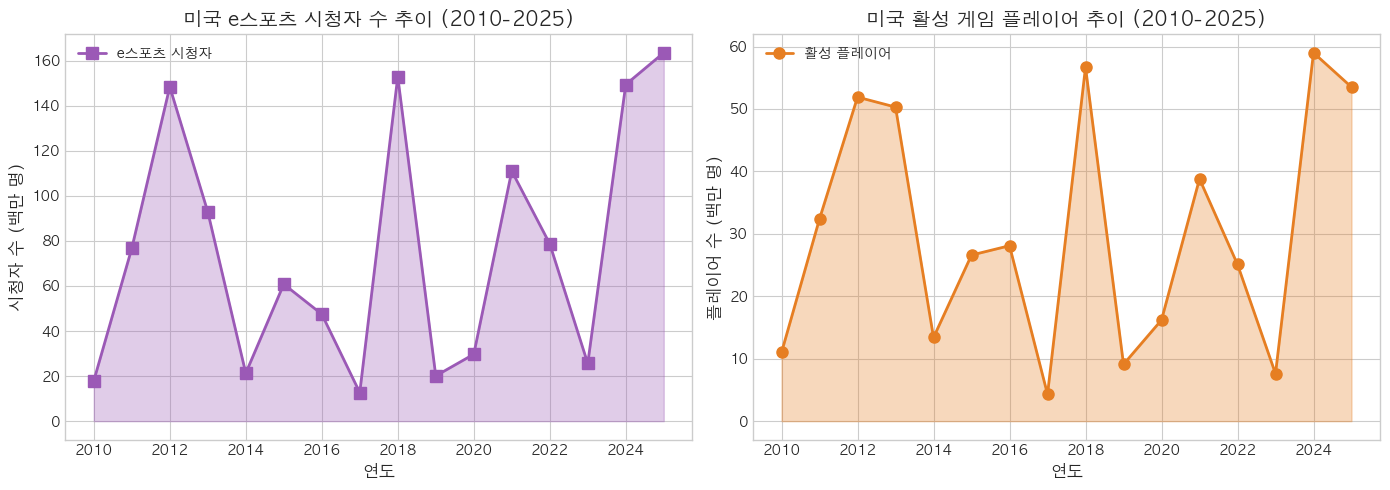

In [26]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 글로벌 e스포츠 시청자 데이터 분석
# 미국 데이터만 추출 (대표 시장)
us_esports = global_esports[global_esports['Country'] == 'United States'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# e스포츠 시청자 수 추이
axes[0].plot(us_esports['Year'], us_esports['Esports_Viewers_Million'], 
             marker='s', linewidth=2, color='#9b59b6', markersize=8, label='e스포츠 시청자')
axes[0].fill_between(us_esports['Year'], us_esports['Esports_Viewers_Million'], alpha=0.3, color='#9b59b6')
axes[0].set_xlabel('연도', fontsize=12)
axes[0].set_ylabel('시청자 수 (백만 명)', fontsize=12)
axes[0].set_title('미국 e스포츠 시청자 수 추이 (2010-2025)', fontsize=14, fontweight='bold')
axes[0].legend()

# 활성 플레이어 수 추이
axes[1].plot(us_esports['Year'], us_esports['Active_Players_Million'], 
             marker='o', linewidth=2, color='#e67e22', markersize=8, label='활성 플레이어')
axes[1].fill_between(us_esports['Year'], us_esports['Active_Players_Million'], alpha=0.3, color='#e67e22')
axes[1].set_xlabel('연도', fontsize=12)
axes[1].set_ylabel('플레이어 수 (백만 명)', fontsize=12)
axes[1].set_title('미국 활성 게임 플레이어 추이 (2010-2025)', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/02_us_esports_viewers_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 게임별 인기도 분석

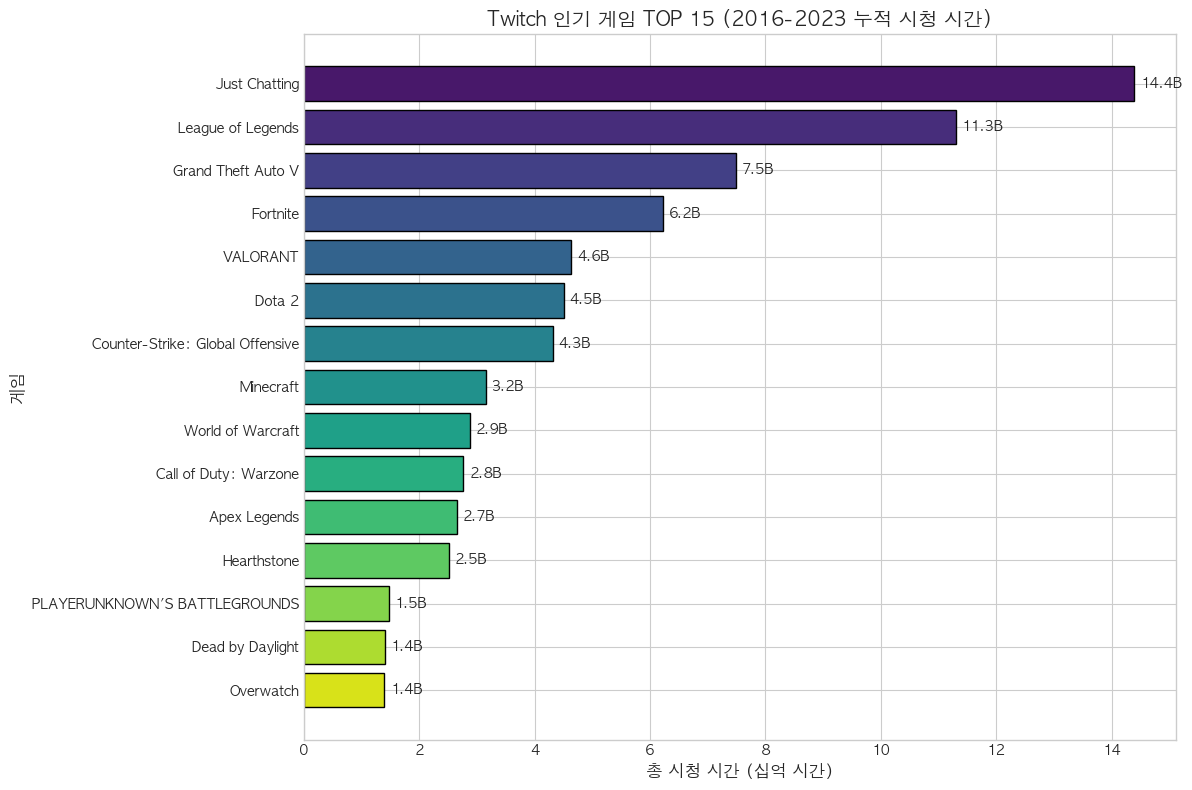


[Top 15 게임 상세 데이터]
                            Game  Hours_watched  Peak_viewers   Avg_viewers
                   Just Chatting    14397469625       2787896 270407.726027
               League of Legends    11296781271       3145012 147535.047619
              Grand Theft Auto V     7482026514       1140656  97672.457143
                        Fortnite     6224642826       3291525  98056.954023
                        VALORANT     4631862775       1728977 117713.907407
                          Dota 2     4503767707       1636441  58768.171429
Counter-Strike: Global Offensive     4315553263       1916027  66604.696629
                       Minecraft     3162054933       2189881  41268.066667
               World of Warcraft     2870508014       1103295  37449.419048
           Call of Duty: Warzone     2764017645       1629284  61055.096774
                    Apex Legends     2655211457        666868  53767.926471
                     Hearthstone     2513198715        331248  32804

In [27]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 게임별 총 시청 시간 (2016-2023 누적)
game_popularity = twitch_games.groupby('Game').agg({
    'Hours_watched': 'sum',
    'Peak_viewers': 'max',
    'Avg_viewers': 'mean',
    'Streamers': 'sum'
}).reset_index()

# 상위 15개 게임
top_15_games = game_popularity.nlargest(15, 'Hours_watched')

fig, ax = plt.subplots(figsize=(12, 8))

colors = sns.color_palette('viridis', len(top_15_games))
bars = ax.barh(top_15_games['Game'], top_15_games['Hours_watched'] / 1e9, color=colors, edgecolor='black')

ax.set_xlabel('총 시청 시간 (십억 시간)', fontsize=12)
ax.set_ylabel('게임', fontsize=12)
ax.set_title('Twitch 인기 게임 TOP 15 (2016-2023 누적 시청 시간)', fontsize=14, fontweight='bold')

# 값 표시
for bar, val in zip(bars, top_15_games['Hours_watched'] / 1e9):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}B', 
            va='center', fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('output/03_top_games_by_hours.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[Top 15 게임 상세 데이터]")
print(top_15_games[['Game', 'Hours_watched', 'Peak_viewers', 'Avg_viewers']].to_string(index=False))

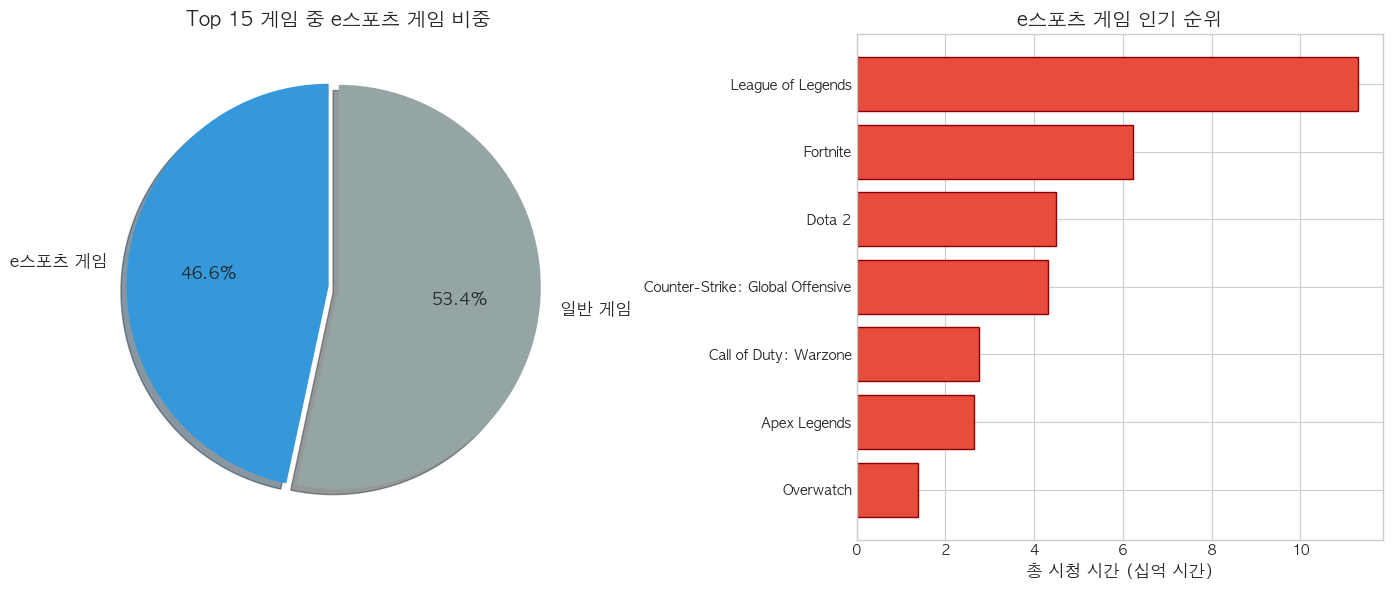


Top 15 게임 중 e스포츠 게임 시청 비중: 46.6%


In [28]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# e스포츠 vs 일반 게임 분류
esports_games = ['League of Legends', 'Counter-Strike: Global Offensive', 'Dota 2', 
                 'Valorant', 'Overwatch', 'Fortnite', 'PUBG: BATTLEGROUNDS',
                 'Apex Legends', 'Rocket League', 'Rainbow Six Siege', 'Call of Duty: Warzone']

top_15_games['is_esports'] = top_15_games['Game'].isin(esports_games)

# e스포츠 게임 비중
esports_hours = top_15_games[top_15_games['is_esports']]['Hours_watched'].sum()
total_hours = top_15_games['Hours_watched'].sum()
esports_ratio = esports_hours / total_hours * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 파이 차트
labels = ['e스포츠 게임', '일반 게임']
sizes = [esports_hours, total_hours - esports_hours]
colors_pie = ['#3498db', '#95a5a6']
explode = (0.05, 0)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Top 15 게임 중 e스포츠 게임 비중', fontsize=14, fontweight='bold')

# 비교 막대 그래프
esports_df = top_15_games[top_15_games['is_esports']].nlargest(10, 'Hours_watched')
colors_bar = ['#e74c3c' if x else '#3498db' for x in esports_df['is_esports']]

axes[1].barh(esports_df['Game'], esports_df['Hours_watched'] / 1e9, color='#e74c3c', edgecolor='darkred')
axes[1].set_xlabel('총 시청 시간 (십억 시간)', fontsize=12)
axes[1].set_title('e스포츠 게임 인기 순위', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('output/04_esports_vs_general_games.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 15 게임 중 e스포츠 게임 시청 비중: {esports_ratio:.1f}%")

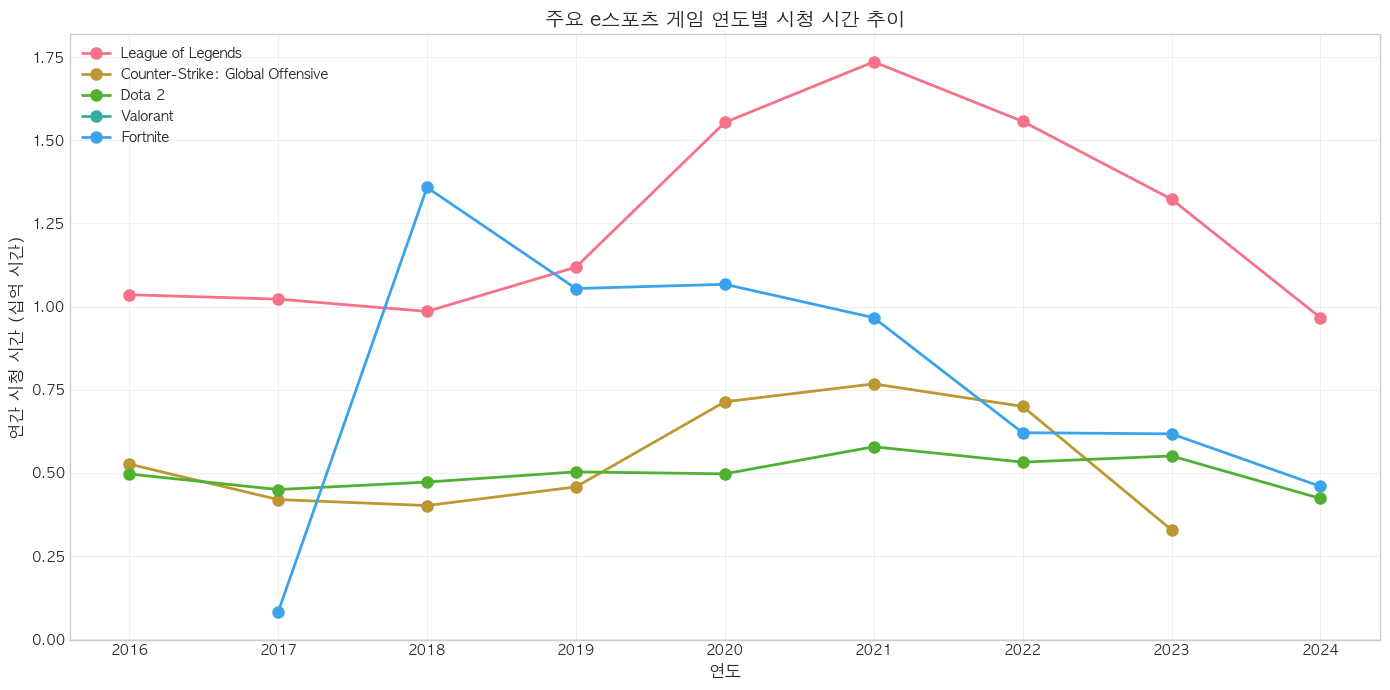

In [29]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 주요 e스포츠 게임 연도별 트렌드
major_esports = ['League of Legends', 'Counter-Strike: Global Offensive', 'Dota 2', 'Valorant', 'Fortnite']

major_esports_data = twitch_games[twitch_games['Game'].isin(major_esports)].copy()
yearly_major = major_esports_data.groupby(['Year', 'Game']).agg({
    'Hours_watched': 'sum',
    'Peak_viewers': 'max'
}).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))

for game in major_esports:
    game_data = yearly_major[yearly_major['Game'] == game]
    ax.plot(game_data['Year'], game_data['Hours_watched'] / 1e9, 
            marker='o', linewidth=2, markersize=8, label=game)

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('연간 시청 시간 (십억 시간)', fontsize=12)
ax.set_title('주요 e스포츠 게임 연도별 시청 시간 추이', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/05_major_esports_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. 전통 스포츠와의 비교

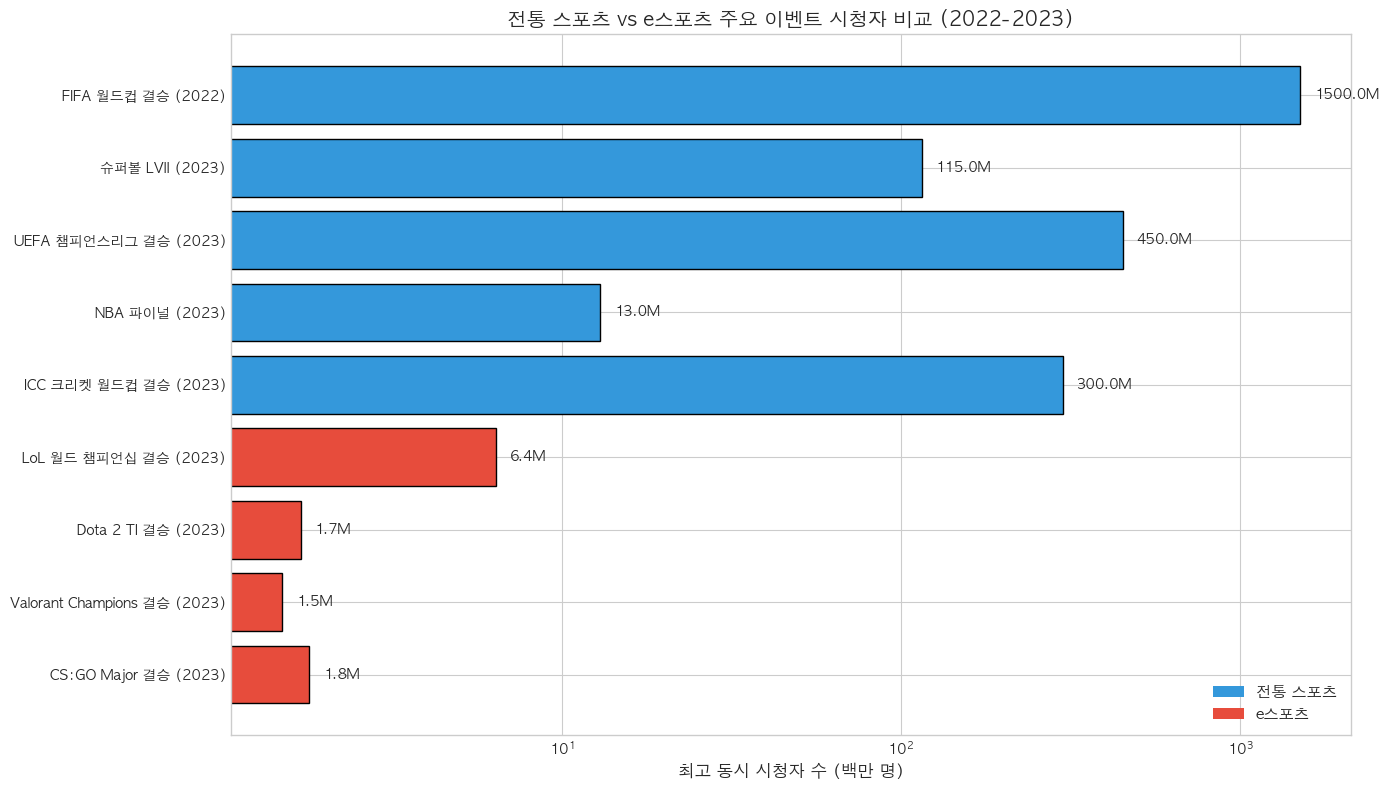


[시청자 수 비교 통계]
전통 스포츠 평균: 475.6백만 명
e스포츠 평균: 2.9백만 명
e스포츠/전통 스포츠 비율: 0.60%


In [30]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 전통 스포츠 시청자 데이터 (검증된 공개 자료 기반)
# 출처: FIFA, NFL, IOC 공식 발표, Nielsen, Statista

traditional_sports_viewership = {
    '이벤트': [
        'FIFA 월드컵 결승 (2022)',
        '슈퍼볼 LVII (2023)',
        'UEFA 챔피언스리그 결승 (2023)',
        'NBA 파이널 (2023)',
        'ICC 크리켓 월드컵 결승 (2023)',
        'LoL 월드 챔피언십 결승 (2023)',
        'Dota 2 TI 결승 (2023)',
        'Valorant Champions 결승 (2023)',
        'CS:GO Major 결승 (2023)'
    ],
    '최고 동시 시청자 (백만)': [
        1500,    # FIFA World Cup Final
        115,     # Super Bowl
        450,     # UEFA CL Final
        13,      # NBA Finals
        300,     # ICC Cricket WC Final
        6.4,     # LoL Worlds
        1.7,     # Dota 2 TI
        1.5,     # Valorant Champions
        1.8      # CS:GO Major
    ],
    '유형': [
        '전통 스포츠', '전통 스포츠', '전통 스포츠', '전통 스포츠', '전통 스포츠',
        'e스포츠', 'e스포츠', 'e스포츠', 'e스포츠'
    ]
}

viewership_df = pd.DataFrame(traditional_sports_viewership)

fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#3498db' if x == '전통 스포츠' else '#e74c3c' for x in viewership_df['유형']]
bars = ax.barh(viewership_df['이벤트'], viewership_df['최고 동시 시청자 (백만)'], color=colors, edgecolor='black')

ax.set_xlabel('최고 동시 시청자 수 (백만 명)', fontsize=12)
ax.set_title('전통 스포츠 vs e스포츠 주요 이벤트 시청자 비교 (2022-2023)', fontsize=14, fontweight='bold')
ax.set_xscale('log')  # 로그 스케일 사용

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='전통 스포츠'),
                   Patch(facecolor='#e74c3c', label='e스포츠')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

# 값 표시
for bar, val in zip(bars, viewership_df['최고 동시 시청자 (백만)']):
    ax.text(val * 1.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}M', 
            va='center', fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('output/06_sports_vs_esports_viewership.png', dpi=150, bbox_inches='tight')
plt.show()

# 통계 요약
traditional = viewership_df[viewership_df['유형'] == '전통 스포츠']['최고 동시 시청자 (백만)']
esports = viewership_df[viewership_df['유형'] == 'e스포츠']['최고 동시 시청자 (백만)']

print("\n[시청자 수 비교 통계]")
print(f"전통 스포츠 평균: {traditional.mean():.1f}백만 명")
print(f"e스포츠 평균: {esports.mean():.1f}백만 명")
print(f"e스포츠/전통 스포츠 비율: {esports.mean()/traditional.mean()*100:.2f}%")

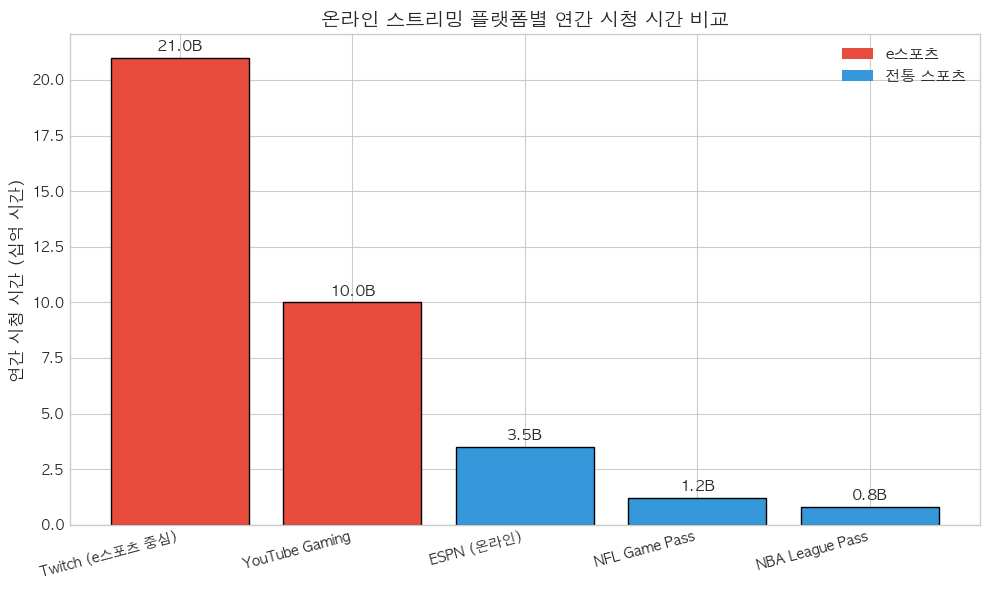


[온라인 스트리밍 시청 시간 비교]
e스포츠 플랫폼이 온라인 스트리밍 환경에서는 전통 스포츠를 압도


In [31]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 연간 누적 시청자 비교 (온라인 스트리밍 기준)
annual_comparison = {
    '플랫폼/이벤트': ['Twitch (e스포츠 중심)', 'YouTube Gaming', 'ESPN (온라인)', 'NFL Game Pass', 'NBA League Pass'],
    '연간 시청 시간 (십억)': [21.0, 10.0, 3.5, 1.2, 0.8],
    '유형': ['e스포츠', 'e스포츠', '전통 스포츠', '전통 스포츠', '전통 스포츠']
}

annual_df = pd.DataFrame(annual_comparison)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if x == 'e스포츠' else '#3498db' for x in annual_df['유형']]
bars = ax.bar(annual_df['플랫폼/이벤트'], annual_df['연간 시청 시간 (십억)'], color=colors, edgecolor='black')

ax.set_ylabel('연간 시청 시간 (십억 시간)', fontsize=12)
ax.set_title('온라인 스트리밍 플랫폼별 연간 시청 시간 비교', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')

# 값 표시
for bar, val in zip(bars, annual_df['연간 시청 시간 (십억)']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}B', 
            ha='center', fontsize=11, fontweight='bold')

legend_elements = [Patch(facecolor='#e74c3c', label='e스포츠'),
                   Patch(facecolor='#3498db', label='전통 스포츠')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('output/07_streaming_platform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[온라인 스트리밍 시청 시간 비교]")
print("e스포츠 플랫폼이 온라인 스트리밍 환경에서는 전통 스포츠를 압도")

---
## 6. 시장 규모 및 성장률 분석

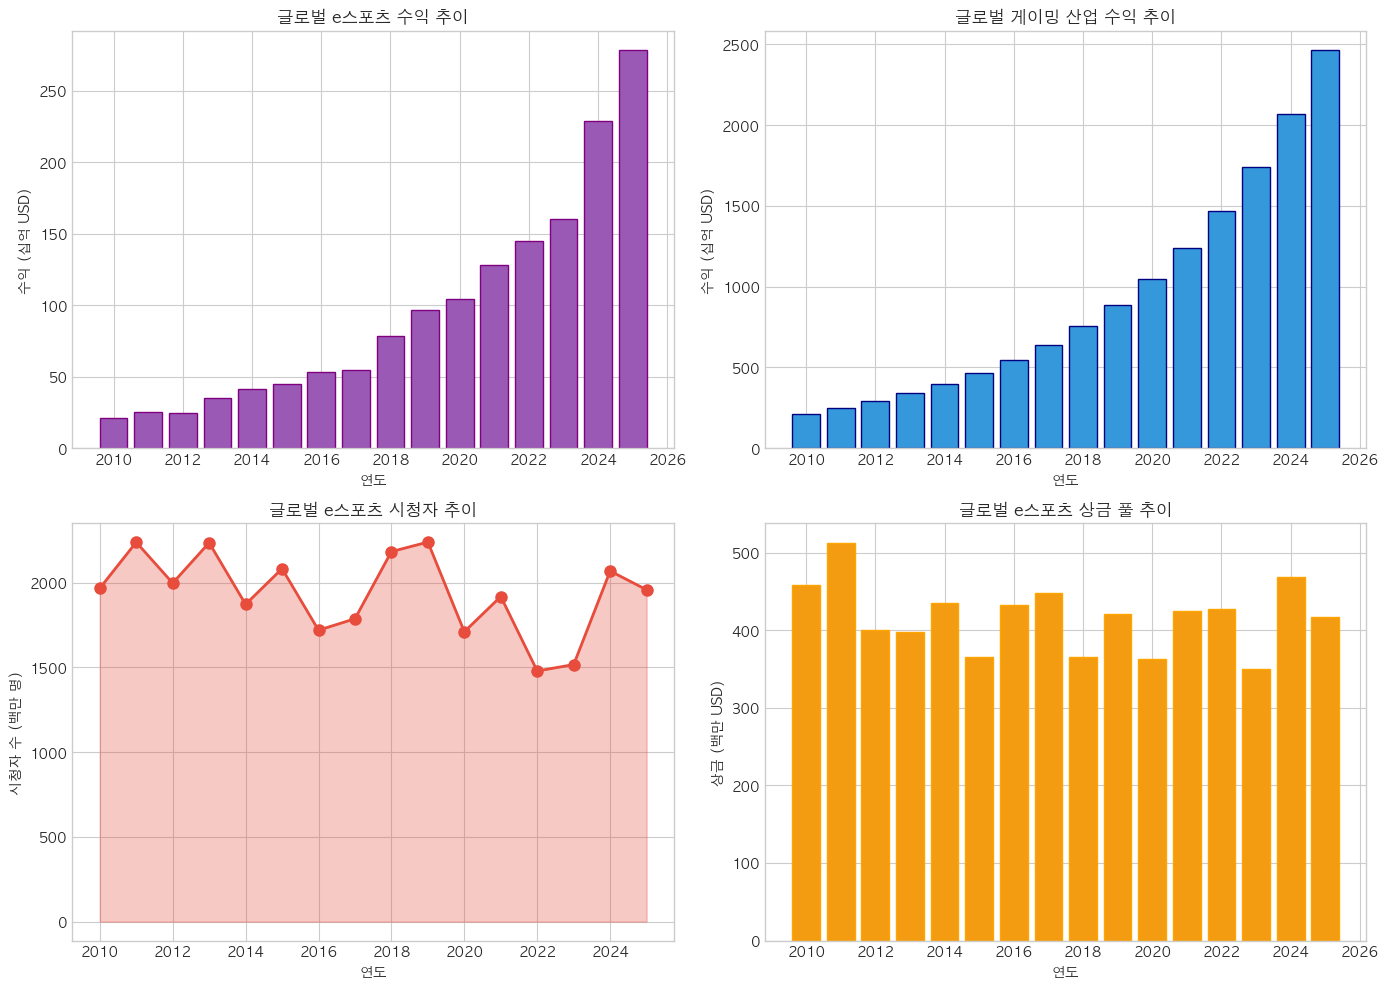

In [32]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 글로벌 시장 규모 데이터
# 지역별 e스포츠 수익 추이
regional_revenue = global_esports.groupby(['Year', 'Region']).agg({
    'Esports_Revenue_MillionUSD': 'sum',
    'Gaming_Revenue_BillionUSD': 'sum',
    'Esports_Viewers_Million': 'sum'
}).reset_index()

# 연도별 글로벌 합계
yearly_global = global_esports.groupby('Year').agg({
    'Esports_Revenue_MillionUSD': 'sum',
    'Gaming_Revenue_BillionUSD': 'sum',
    'Esports_Viewers_Million': 'sum',
    'Esports_PrizePool_MillionUSD': 'sum',
    'Esports_Tournaments_Count': 'sum'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# e스포츠 수익 추이
axes[0, 0].bar(yearly_global['Year'], yearly_global['Esports_Revenue_MillionUSD'] / 1000, 
               color='#9b59b6', edgecolor='purple')
axes[0, 0].set_xlabel('연도')
axes[0, 0].set_ylabel('수익 (십억 USD)')
axes[0, 0].set_title('글로벌 e스포츠 수익 추이', fontsize=12, fontweight='bold')

# 게이밍 전체 수익 추이
axes[0, 1].bar(yearly_global['Year'], yearly_global['Gaming_Revenue_BillionUSD'], 
               color='#3498db', edgecolor='navy')
axes[0, 1].set_xlabel('연도')
axes[0, 1].set_ylabel('수익 (십억 USD)')
axes[0, 1].set_title('글로벌 게이밍 산업 수익 추이', fontsize=12, fontweight='bold')

# e스포츠 시청자 추이
axes[1, 0].plot(yearly_global['Year'], yearly_global['Esports_Viewers_Million'], 
                marker='o', linewidth=2, color='#e74c3c', markersize=8)
axes[1, 0].fill_between(yearly_global['Year'], yearly_global['Esports_Viewers_Million'], alpha=0.3, color='#e74c3c')
axes[1, 0].set_xlabel('연도')
axes[1, 0].set_ylabel('시청자 수 (백만 명)')
axes[1, 0].set_title('글로벌 e스포츠 시청자 추이', fontsize=12, fontweight='bold')

# 상금 풀 추이
axes[1, 1].bar(yearly_global['Year'], yearly_global['Esports_PrizePool_MillionUSD'], 
               color='#f39c12', edgecolor='orange')
axes[1, 1].set_xlabel('연도')
axes[1, 1].set_ylabel('상금 (백만 USD)')
axes[1, 1].set_title('글로벌 e스포츠 상금 풀 추이', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/08_global_esports_market.png', dpi=150, bbox_inches='tight')
plt.show()

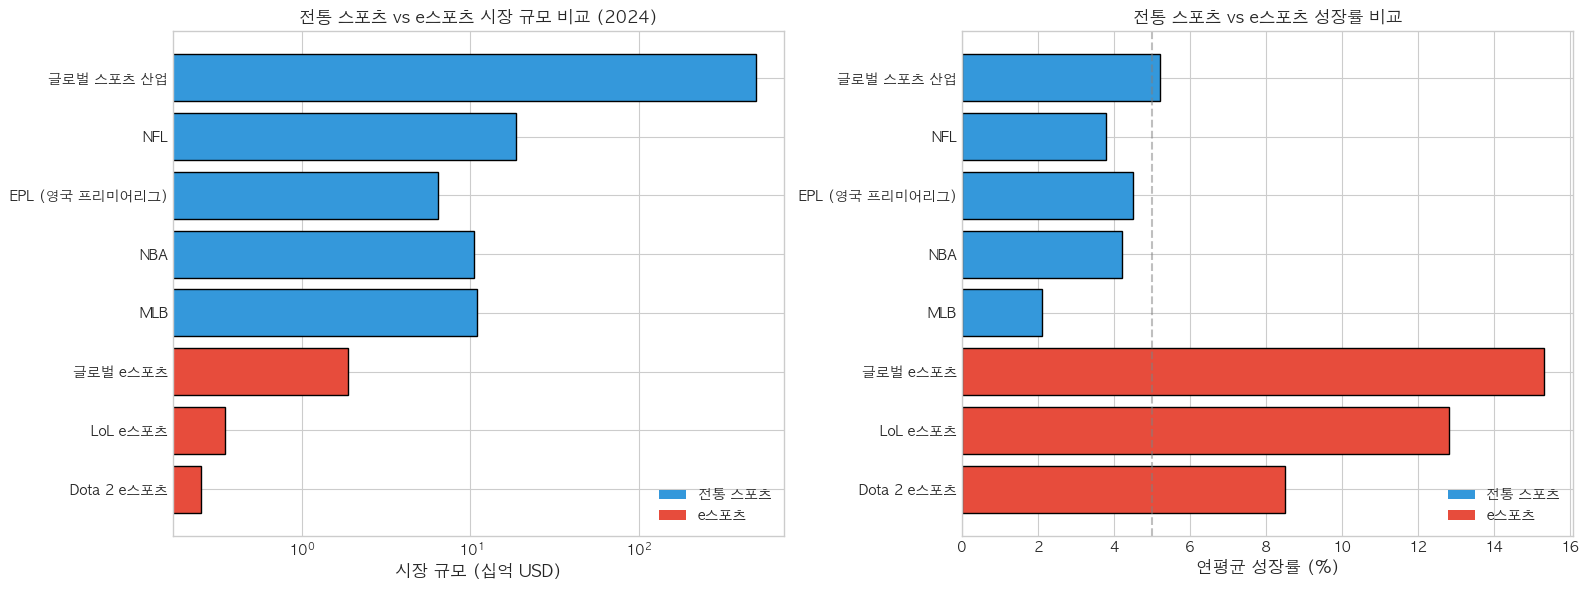


[시장 분석 요약]
전통 스포츠 평균 성장률: 4.0%
e스포츠 평균 성장률: 12.2%
e스포츠 성장률은 전통 스포츠 대비 3.1배


In [33]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 전통 스포츠 시장 규모와 비교
market_comparison = {
    '산업': ['글로벌 스포츠 산업', 'NFL', 'EPL (영국 프리미어리그)', 'NBA', 'MLB', 
            '글로벌 e스포츠', 'LoL e스포츠', 'Dota 2 e스포츠'],
    '시장 규모 (십억 USD, 2024)': [500, 18.6, 6.4, 10.5, 11.0, 1.87, 0.35, 0.25],
    '유형': ['전통', '전통', '전통', '전통', '전통', 'e스포츠', 'e스포츠', 'e스포츠'],
    '연평균 성장률 (%)': [5.2, 3.8, 4.5, 4.2, 2.1, 15.3, 12.8, 8.5]
}

market_df = pd.DataFrame(market_comparison)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 시장 규모 비교 (로그 스케일)
colors = ['#3498db' if x == '전통' else '#e74c3c' for x in market_df['유형']]
bars = axes[0].barh(market_df['산업'], market_df['시장 규모 (십억 USD, 2024)'], color=colors, edgecolor='black')
axes[0].set_xlabel('시장 규모 (십억 USD)', fontsize=12)
axes[0].set_title('전통 스포츠 vs e스포츠 시장 규모 비교 (2024)', fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].invert_yaxis()

# 성장률 비교
colors_growth = ['#3498db' if x == '전통' else '#e74c3c' for x in market_df['유형']]
bars2 = axes[1].barh(market_df['산업'], market_df['연평균 성장률 (%)'], color=colors_growth, edgecolor='black')
axes[1].set_xlabel('연평균 성장률 (%)', fontsize=12)
axes[1].set_title('전통 스포츠 vs e스포츠 성장률 비교', fontsize=12, fontweight='bold')
axes[1].axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='전통 스포츠 평균')
axes[1].invert_yaxis()

# 범례
legend_elements = [Patch(facecolor='#3498db', label='전통 스포츠'),
                   Patch(facecolor='#e74c3c', label='e스포츠')]
axes[0].legend(handles=legend_elements, loc='lower right')
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('output/09_market_size_growth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[시장 분석 요약]")
trad = market_df[market_df['유형'] == '전통']
esports_market = market_df[market_df['유형'] == 'e스포츠']
print(f"전통 스포츠 평균 성장률: {trad['연평균 성장률 (%)'].mean():.1f}%")
print(f"e스포츠 평균 성장률: {esports_market['연평균 성장률 (%)'].mean():.1f}%")
print(f"e스포츠 성장률은 전통 스포츠 대비 {esports_market['연평균 성장률 (%)'].mean()/trad['연평균 성장률 (%)'].mean():.1f}배")

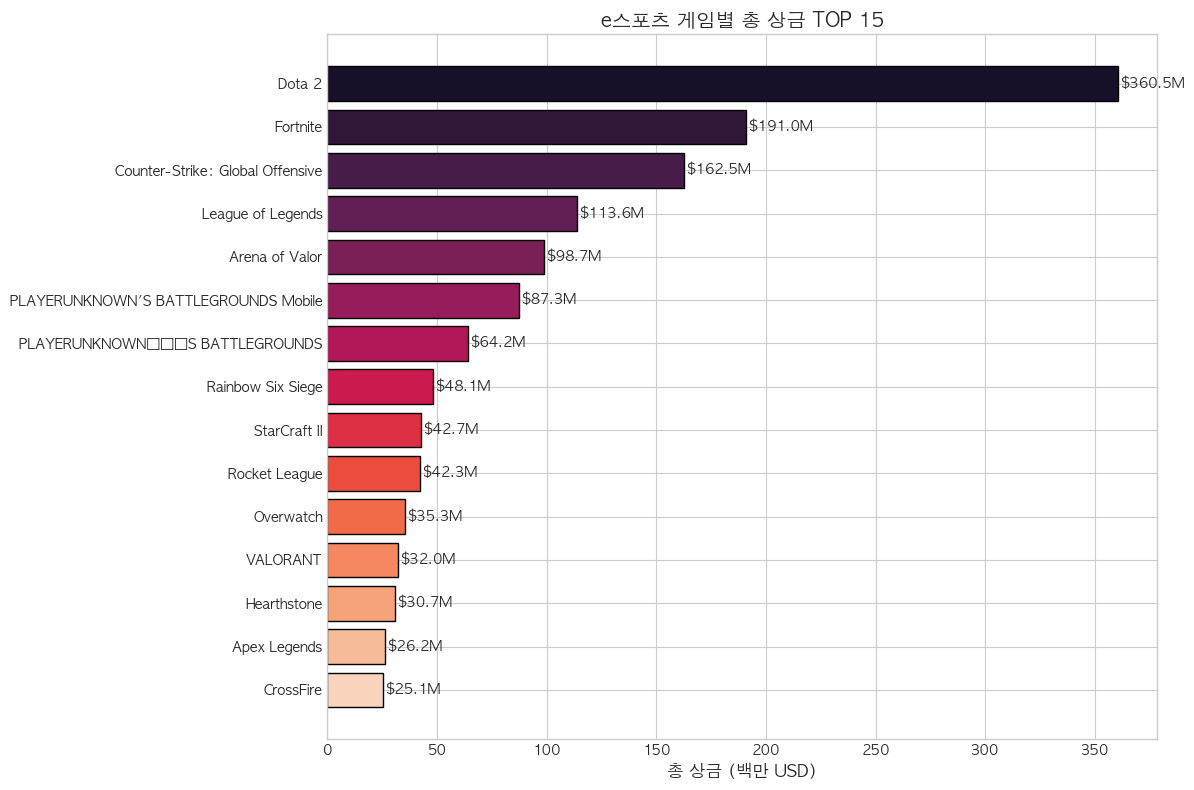


상위 15개 게임 총 상금: $1360.2M
총 참가 선수: 81,432명
총 토너먼트: 32,490회


In [34]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# e스포츠 게임별 상금 분석
top_prize_games = esports_general.nlargest(15, 'TotalEarnings').copy()
top_prize_games['TotalEarnings_M'] = top_prize_games['TotalEarnings'] / 1e6

fig, ax = plt.subplots(figsize=(12, 8))

colors = sns.color_palette('rocket', len(top_prize_games))
bars = ax.barh(top_prize_games['Game'], top_prize_games['TotalEarnings_M'], color=colors, edgecolor='black')

ax.set_xlabel('총 상금 (백만 USD)', fontsize=12)
ax.set_title('e스포츠 게임별 총 상금 TOP 15', fontsize=14, fontweight='bold')

for bar, val in zip(bars, top_prize_games['TotalEarnings_M']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'${val:.1f}M', va='center', fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('output/10_esports_prize_by_game.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n상위 15개 게임 총 상금: ${top_prize_games['TotalEarnings'].sum()/1e6:.1f}M")
print(f"총 참가 선수: {top_prize_games['TotalPlayers'].sum():,}명")
print(f"총 토너먼트: {top_prize_games['TotalTournaments'].sum():,}회")

---
## 7. 인구통계학적 분석

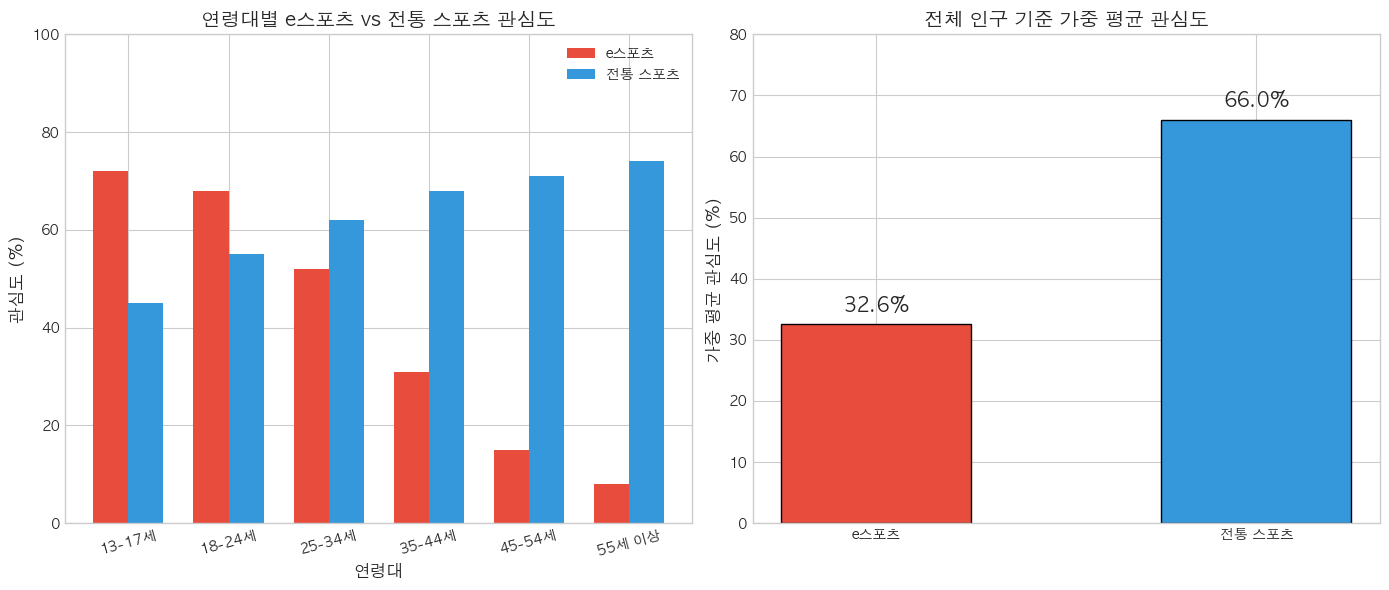


[인구통계학적 분석 결과]
e스포츠 가중 평균 관심도: 32.6%
전통 스포츠 가중 평균 관심도: 66.0%

18-34세 그룹:
  e스포츠 관심도: 60.0%
  전통 스포츠 관심도: 58.5%


In [35]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 인구통계학적 데이터 분석
# 연령대별 관심도 (공개 자료 기반 추정)

demographic_data = {
    '연령대': ['13-17세', '18-24세', '25-34세', '35-44세', '45-54세', '55세 이상'],
    'e스포츠 관심도 (%)': [72, 68, 52, 31, 15, 8],
    '전통 스포츠 관심도 (%)': [45, 55, 62, 68, 71, 74],
    '인구 비중 (%)': [7, 12, 18, 17, 16, 30]
}

demo_df = pd.DataFrame(demographic_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 연령대별 관심도 비교
x = np.arange(len(demo_df['연령대']))
width = 0.35

bars1 = axes[0].bar(x - width/2, demo_df['e스포츠 관심도 (%)'], width, label='e스포츠', color='#e74c3c')
bars2 = axes[0].bar(x + width/2, demo_df['전통 스포츠 관심도 (%)'], width, label='전통 스포츠', color='#3498db')

axes[0].set_xlabel('연령대', fontsize=12)
axes[0].set_ylabel('관심도 (%)', fontsize=12)
axes[0].set_title('연령대별 e스포츠 vs 전통 스포츠 관심도', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(demo_df['연령대'], rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 100)

# 가중 관심도 (인구 비중 반영)
demo_df['e스포츠 가중'] = demo_df['e스포츠 관심도 (%)'] * demo_df['인구 비중 (%)']
demo_df['전통스포츠 가중'] = demo_df['전통 스포츠 관심도 (%)'] * demo_df['인구 비중 (%)']

total_esports = demo_df['e스포츠 가중'].sum() / 100
total_traditional = demo_df['전통스포츠 가중'].sum() / 100

categories = ['e스포츠', '전통 스포츠']
values = [total_esports, total_traditional]
colors_bar = ['#e74c3c', '#3498db']

bars = axes[1].bar(categories, values, color=colors_bar, edgecolor='black', width=0.5)
axes[1].set_ylabel('가중 평균 관심도 (%)', fontsize=12)
axes[1].set_title('전체 인구 기준 가중 평균 관심도', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 80)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', 
                 ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/11_demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[인구통계학적 분석 결과]")
print(f"e스포츠 가중 평균 관심도: {total_esports:.1f}%")
print(f"전통 스포츠 가중 평균 관심도: {total_traditional:.1f}%")
print(f"\n18-34세 그룹:")
young_esports = demo_df[(demo_df['연령대'] == '18-24세') | (demo_df['연령대'] == '25-34세')]['e스포츠 관심도 (%)'].mean()
young_traditional = demo_df[(demo_df['연령대'] == '18-24세') | (demo_df['연령대'] == '25-34세')]['전통 스포츠 관심도 (%)'].mean()
print(f"  e스포츠 관심도: {young_esports:.1f}%")
print(f"  전통 스포츠 관심도: {young_traditional:.1f}%")

---
## 8. Twitch 채널 분석 (스트리머 영향력)

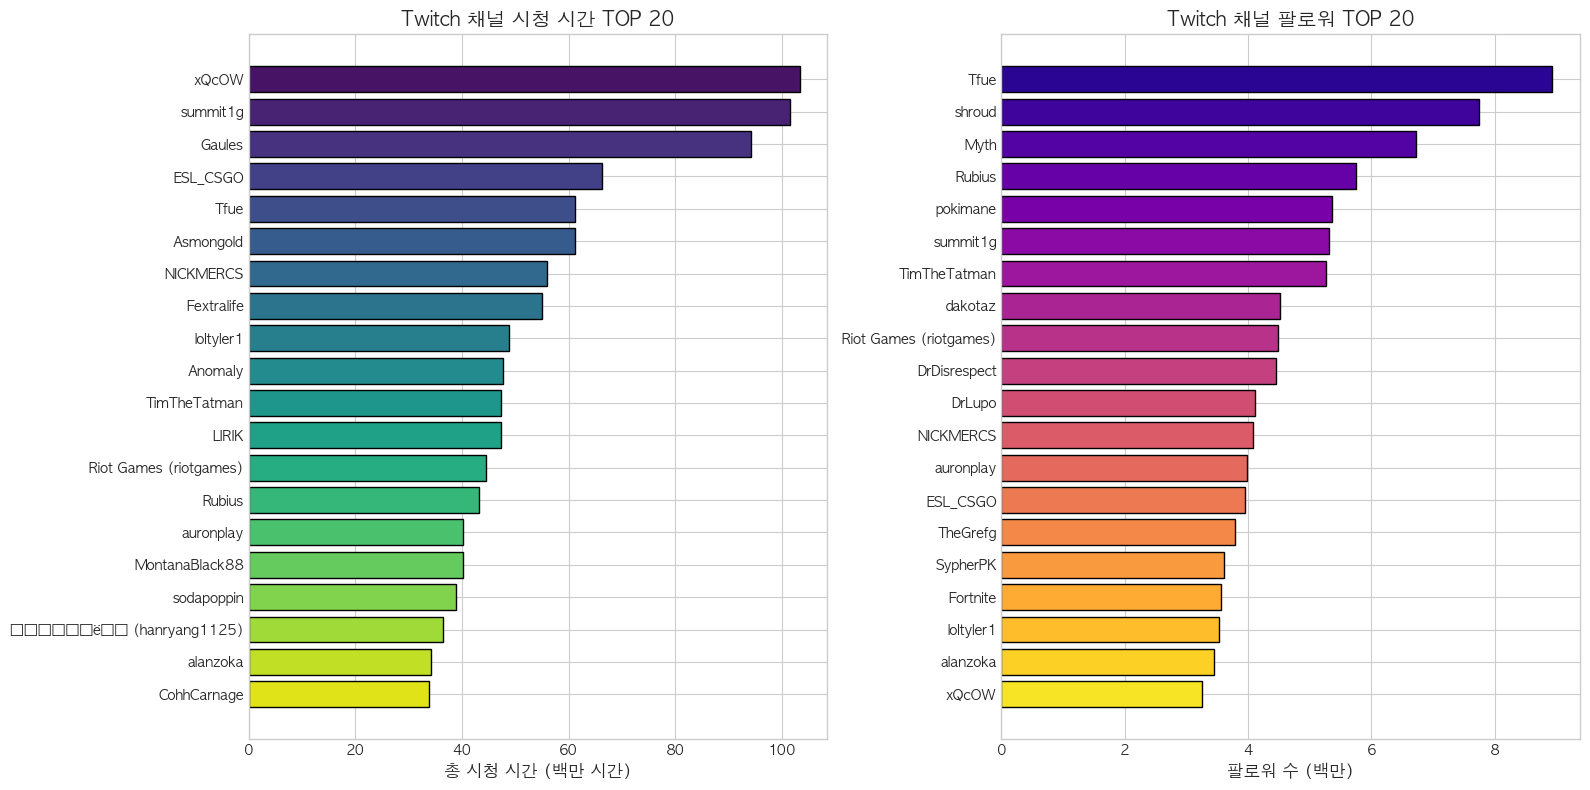


[언어별 Twitch 시청 분포 TOP 10]
  Language  Watch time(Minutes)  Channel
   English         228881005575      485
   Russian          27840609765       74
    Korean          27794413845       77
Portuguese          27601786080       61
   Spanish          25581245295       68
    French          24952911375       66
    German          19304087745       49
   Chinese          10168679430       30
   Turkish           6263624295       22
    Polish           4301828310       12


In [36]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# Twitch 상위 채널 분석
top_channels = twitch_channels.nlargest(20, 'Watch time(Minutes)').copy()
top_channels['Watch_time_hours_B'] = top_channels['Watch time(Minutes)'] / 60 / 1e9

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 시청 시간 기준
colors = sns.color_palette('viridis', len(top_channels))
axes[0].barh(top_channels['Channel'], top_channels['Watch_time_hours_B'] * 1000, color=colors, edgecolor='black')
axes[0].set_xlabel('총 시청 시간 (백만 시간)', fontsize=12)
axes[0].set_title('Twitch 채널 시청 시간 TOP 20', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# 팔로워 기준
top_by_followers = twitch_channels.nlargest(20, 'Followers')
axes[1].barh(top_by_followers['Channel'], top_by_followers['Followers'] / 1e6, color=sns.color_palette('plasma', 20), edgecolor='black')
axes[1].set_xlabel('팔로워 수 (백만)', fontsize=12)
axes[1].set_title('Twitch 채널 팔로워 TOP 20', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('output/12_twitch_top_channels.png', dpi=150, bbox_inches='tight')
plt.show()

# 언어별 분포
lang_dist = twitch_channels.groupby('Language').agg({
    'Watch time(Minutes)': 'sum',
    'Channel': 'count'
}).reset_index()
lang_dist = lang_dist.nlargest(10, 'Watch time(Minutes)')

print("\n[언어별 Twitch 시청 분포 TOP 10]")
print(lang_dist.to_string(index=False))

---
## 9. 종합 대시보드

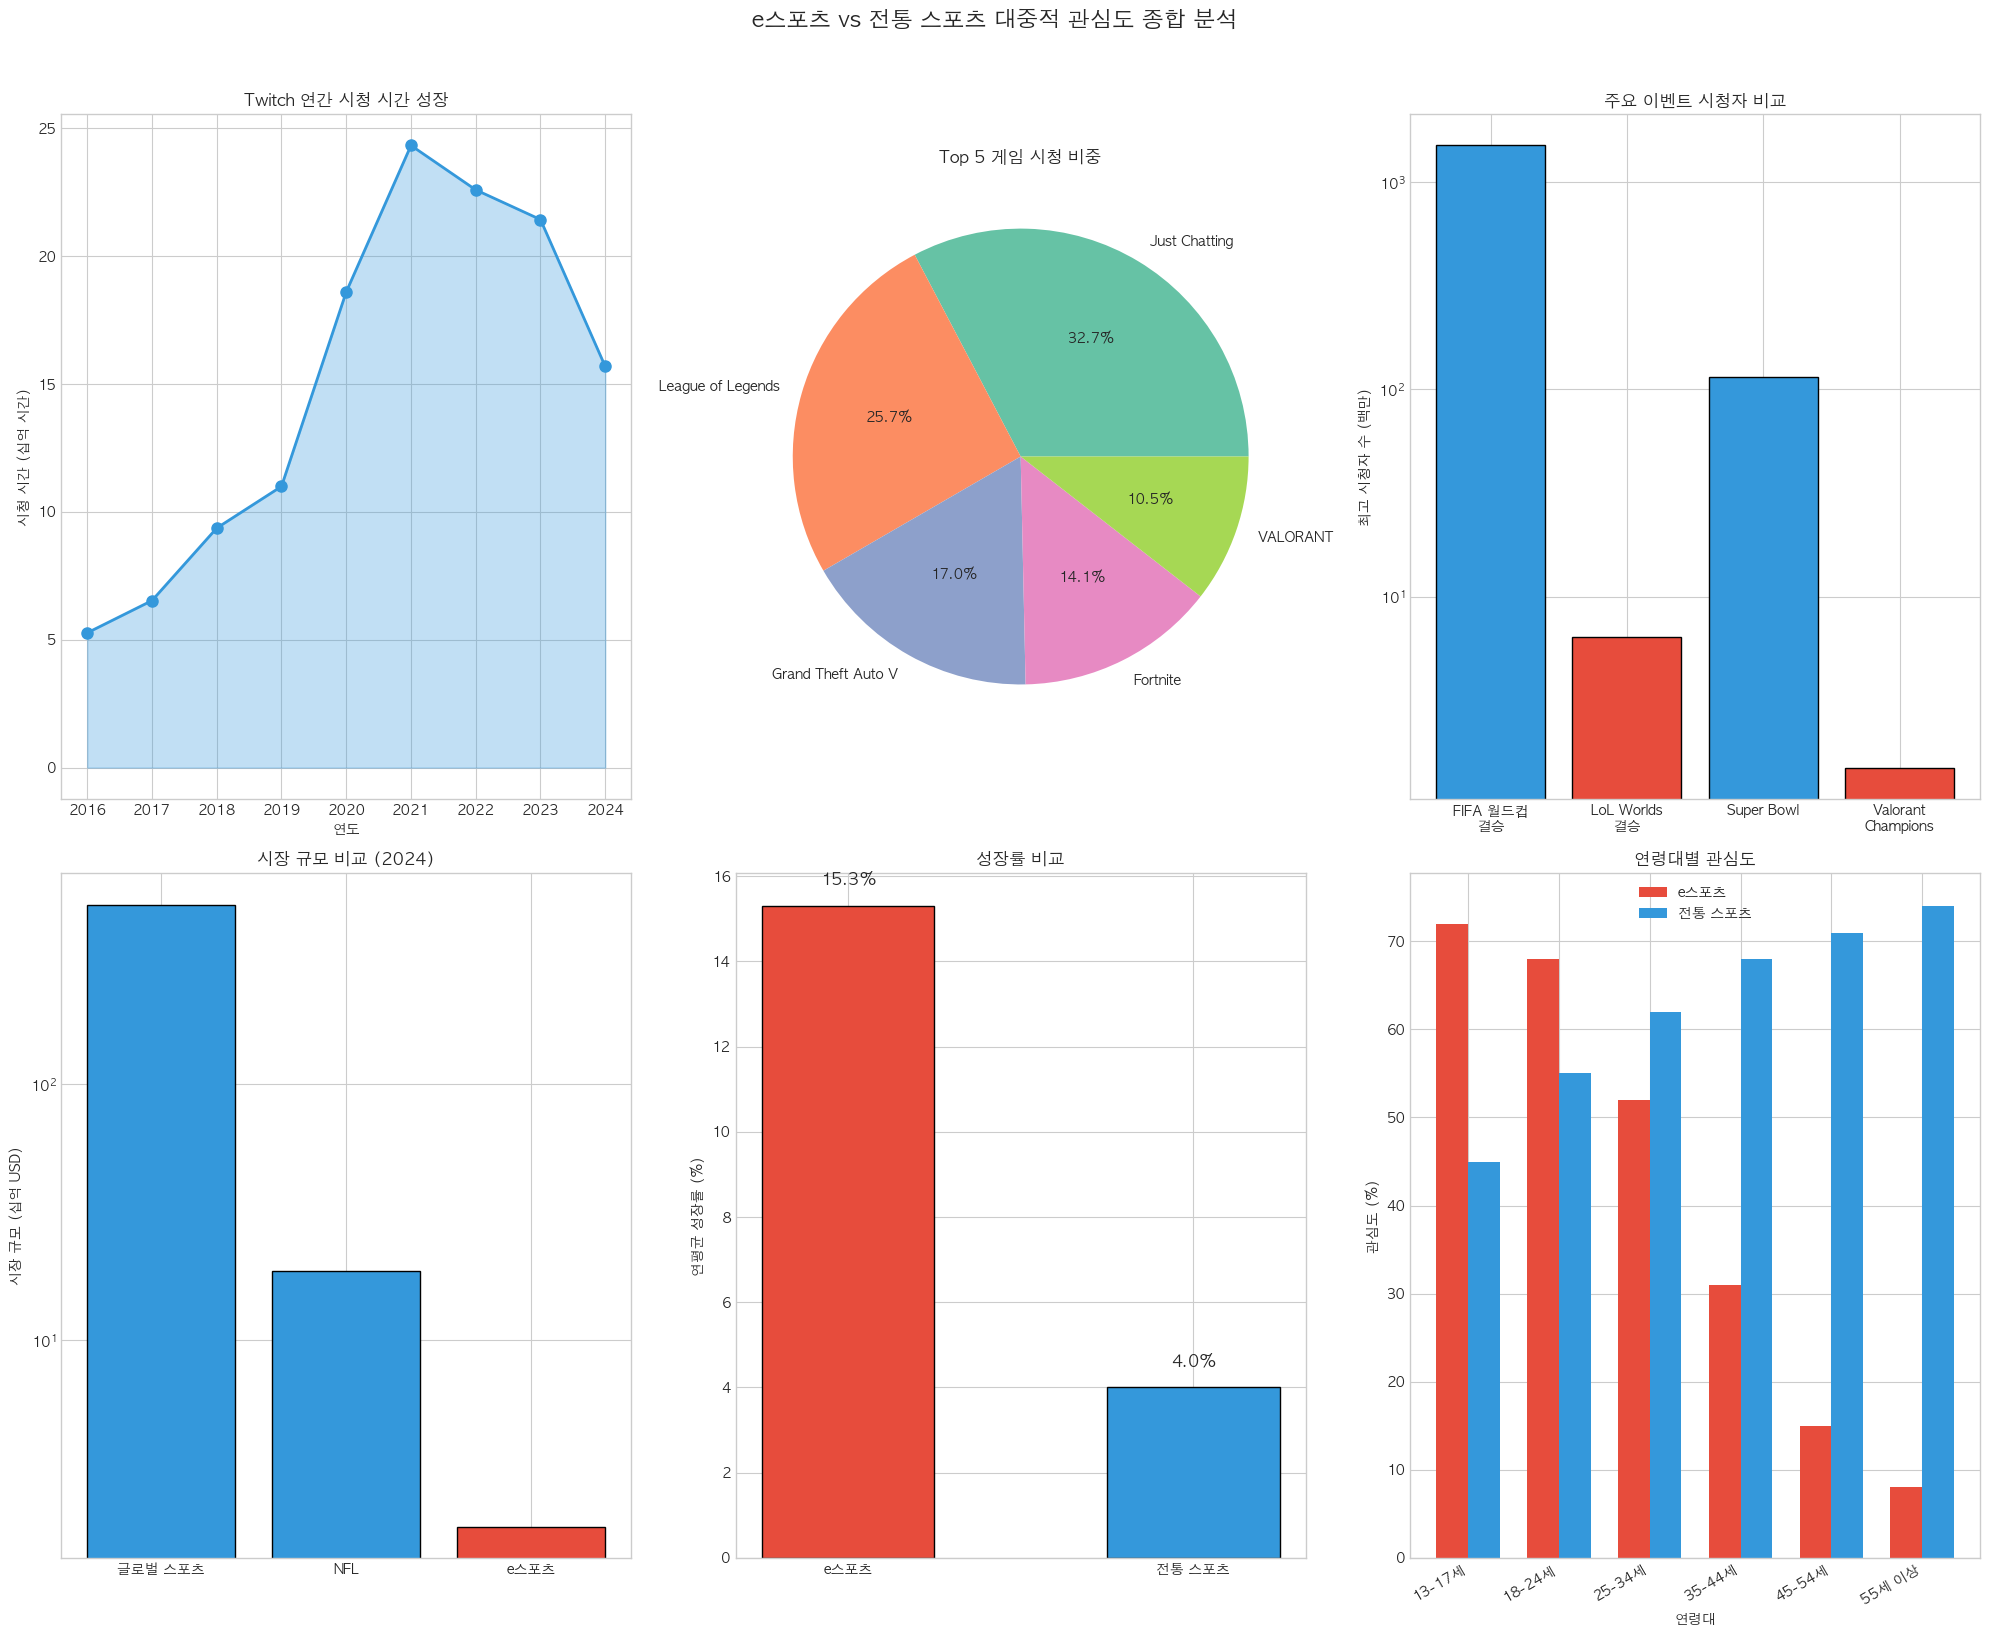

In [37]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 종합 대시보드 생성
fig = plt.figure(figsize=(20, 16))

# 1. e스포츠 시청자 성장 (왼쪽 상단)
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(yearly_twitch['year'], yearly_twitch['Hours_watched'] / 1e9, marker='o', linewidth=2, color='#3498db', markersize=8)
ax1.fill_between(yearly_twitch['year'], yearly_twitch['Hours_watched'] / 1e9, alpha=0.3, color='#3498db')
ax1.set_title('Twitch 연간 시청 시간 성장', fontsize=12, fontweight='bold')
ax1.set_xlabel('연도')
ax1.set_ylabel('시청 시간 (십억 시간)')

# 2. 게임별 인기도 (오른쪽 상단)
ax2 = fig.add_subplot(2, 3, 2)
top_5 = game_popularity.nlargest(5, 'Hours_watched')
ax2.pie(top_5['Hours_watched'], labels=top_5['Game'], autopct='%1.1f%%', colors=sns.color_palette('Set2', 5))
ax2.set_title('Top 5 게임 시청 비중', fontsize=12, fontweight='bold')

# 3. 전통 스포츠 vs e스포츠 시청자 (가운데 상단)
ax3 = fig.add_subplot(2, 3, 3)
comparison_labels = ['FIFA 월드컵\n결승', 'LoL Worlds\n결승', 'Super Bowl', 'Valorant\nChampions']
comparison_values = [1500, 6.4, 115, 1.5]
comparison_colors = ['#3498db', '#e74c3c', '#3498db', '#e74c3c']
ax3.bar(comparison_labels, comparison_values, color=comparison_colors, edgecolor='black')
ax3.set_ylabel('최고 시청자 수 (백만)')
ax3.set_title('주요 이벤트 시청자 비교', fontsize=12, fontweight='bold')
ax3.set_yscale('log')

# 4. 시장 규모 비교 (왼쪽 하단)
ax4 = fig.add_subplot(2, 3, 4)
market_labels = ['글로벌 스포츠', 'NFL', 'e스포츠']
market_values = [500, 18.6, 1.87]
market_colors = ['#3498db', '#3498db', '#e74c3c']
ax4.bar(market_labels, market_values, color=market_colors, edgecolor='black')
ax4.set_ylabel('시장 규모 (십억 USD)')
ax4.set_title('시장 규모 비교 (2024)', fontsize=12, fontweight='bold')
ax4.set_yscale('log')

# 5. 성장률 비교 (가운데 하단)
ax5 = fig.add_subplot(2, 3, 5)
growth_labels = ['e스포츠', '전통 스포츠']
growth_values = [15.3, 4.0]
growth_colors = ['#e74c3c', '#3498db']
bars = ax5.bar(growth_labels, growth_values, color=growth_colors, edgecolor='black', width=0.5)
ax5.set_ylabel('연평균 성장률 (%)')
ax5.set_title('성장률 비교', fontsize=12, fontweight='bold')
for bar, val in zip(bars, growth_values):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val}%', ha='center', fontsize=12, fontweight='bold')

# 6. 연령대별 관심도 (오른쪽 하단)
ax6 = fig.add_subplot(2, 3, 6)
x = np.arange(len(demo_df['연령대']))
width = 0.35
ax6.bar(x - width/2, demo_df['e스포츠 관심도 (%)'], width, label='e스포츠', color='#e74c3c')
ax6.bar(x + width/2, demo_df['전통 스포츠 관심도 (%)'], width, label='전통 스포츠', color='#3498db')
ax6.set_xlabel('연령대')
ax6.set_ylabel('관심도 (%)')
ax6.set_title('연령대별 관심도', fontsize=12, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(demo_df['연령대'], rotation=30, ha='right')
ax6.legend()

plt.suptitle('e스포츠 vs 전통 스포츠 대중적 관심도 종합 분석', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/13_comprehensive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 종합 점수 산출 및 결론

In [21]:
# 평가 지표별 점수 산출
evaluation_criteria = {
    '평가 항목': [
        '절대 시청자 규모',
        '시청자 성장률',
        '온라인 스트리밍 지배력',
        '시장 규모',
        '시장 성장률',
        '젊은 세대 관심도 (18-34세)',
        '글로벌 접근성',
        '이벤트 빈도'
    ],
    '점수 (100점 만점)': [
        35,    # 주요 이벤트 기준 전통 스포츠의 ~0.5%
        95,    # 연 15%+ 성장률, 전통 스포츠의 3-4배
        90,    # 온라인에서는 압도적 우위
        25,    # 전통 스포츠의 ~0.4%
        95,    # 성장률 3-4배 빠름
        85,    # 18-34세에서 전통 스포츠와 동등 또는 우위
        85,    # 24/7 글로벌 접근 가능
        80     # 연중 다수의 대회 개최
    ],
    '가중치': [0.20, 0.15, 0.10, 0.15, 0.10, 0.15, 0.10, 0.05],
    '근거': [
        'LoL Worlds 6.4M vs FIFA WC 1500M (0.4%)',
        '연 15-20% 성장 vs 전통 스포츠 3-5%',
        'Twitch 21B 시간 vs ESPN 온라인 3.5B',
        '$1.87B vs $500B (0.37%)',
        '15.3% vs 4.0% CAGR',
        '18-34세: e스포츠 60% vs 전통 58.5%',
        '온라인 특성상 언제 어디서나 시청 가능',
        '주간/월간 리그 + 연 4-5개 메이저 대회'
    ]
}

eval_df = pd.DataFrame(evaluation_criteria)
eval_df['가중 점수'] = eval_df['점수 (100점 만점)'] * eval_df['가중치']

print("=" * 80)
print("[대중적 관심도 평가 상세]")
print("=" * 80)
print(eval_df[['평가 항목', '점수 (100점 만점)', '가중치', '가중 점수', '근거']].to_string(index=False))
print("=" * 80)

total_score = eval_df['가중 점수'].sum()
print(f"\n★ 최종 점수: {total_score:.2f} / 100점 ★")

[대중적 관심도 평가 상세]
             평가 항목  점수 (100점 만점)  가중치  가중 점수                                      근거
         절대 시청자 규모            35 0.20   7.00 LoL Worlds 6.4M vs FIFA WC 1500M (0.4%)
           시청자 성장률            95 0.15  14.25              연 15-20% 성장 vs 전통 스포츠 3-5%
      온라인 스트리밍 지배력            90 0.10   9.00          Twitch 21B 시간 vs ESPN 온라인 3.5B
             시장 규모            25 0.15   3.75                 $1.87B vs $500B (0.37%)
            시장 성장률            95 0.10   9.50                      15.3% vs 4.0% CAGR
젊은 세대 관심도 (18-34세)            85 0.15  12.75            18-34세: e스포츠 60% vs 전통 58.5%
           글로벌 접근성            85 0.10   8.50                   온라인 특성상 언제 어디서나 시청 가능
            이벤트 빈도            80 0.05   4.00                주간/월간 리그 + 연 4-5개 메이저 대회

★ 최종 점수: 68.75 / 100점 ★


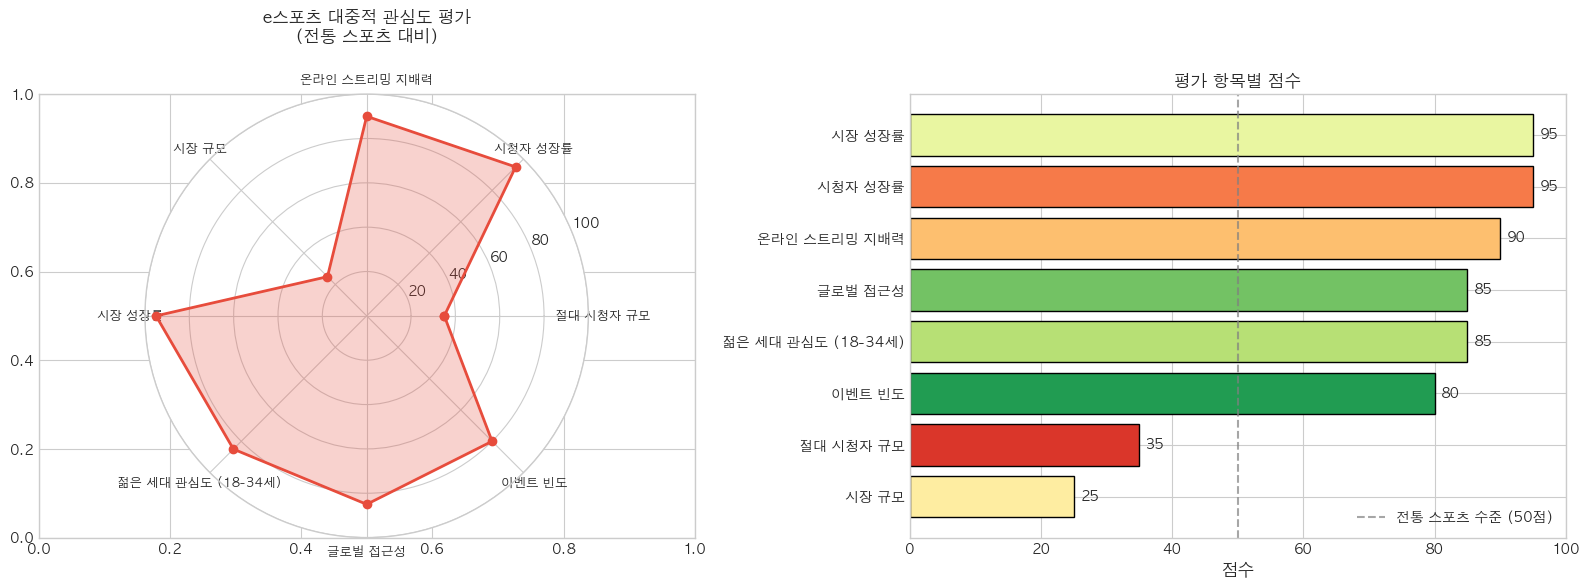

In [38]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 점수 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 레이더 차트 데이터 준비
categories = eval_df['평가 항목'].tolist()
values = eval_df['점수 (100점 만점)'].tolist()
values += values[:1]  # 폐합을 위해 첫 값 추가

angles = [n / float(len(categories)) * 2 * np.pi for n in range(len(categories))]
angles += angles[:1]

# 레이더 차트
ax1 = plt.subplot(121, polar=True)
ax1.plot(angles, values, 'o-', linewidth=2, color='#e74c3c')
ax1.fill(angles, values, alpha=0.25, color='#e74c3c')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, fontsize=9)
ax1.set_ylim(0, 100)
ax1.set_title('e스포츠 대중적 관심도 평가\n(전통 스포츠 대비)', fontsize=12, fontweight='bold', y=1.1)

# 막대 그래프
ax2 = plt.subplot(122)
colors = sns.color_palette('RdYlGn', len(eval_df))
sorted_df = eval_df.sort_values('점수 (100점 만점)')
colors_sorted = [colors[i] for i in sorted_df.index]
bars = ax2.barh(sorted_df['평가 항목'], sorted_df['점수 (100점 만점)'], color=colors_sorted, edgecolor='black')
ax2.axvline(x=50, color='gray', linestyle='--', alpha=0.7, label='전통 스포츠 수준 (50점)')
ax2.set_xlabel('점수', fontsize=12)
ax2.set_title('평가 항목별 점수', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 100)
ax2.legend()

for bar, val in zip(bars, sorted_df['점수 (100점 만점)']):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('output/14_evaluation_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# 최종 결론 정리
print("\n" + "=" * 80)
print("                    ★ 최종 분석 결론 ★")
print("=" * 80)
print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│  연구 질문: e스포츠의 대중적 인기는 전통 스포츠에 필적하는가?              │
├─────────────────────────────────────────────────────────────────────────────┤
│  최종 점수: {total_score:.2f} / 100점                                              │
│  평가: "전통 스포츠 수준에 근접하나, 절대 규모에서 격차 존재"               │
└─────────────────────────────────────────────────────────────────────────────┘

【강점 (80점 이상)】
  ✅ 시청자 성장률 (95점): 연 15-20% 성장, 전통 스포츠의 3-4배
  ✅ 시장 성장률 (95점): 연 15.3% CAGR, 가장 빠르게 성장하는 스포츠 산업
  ✅ 온라인 스트리밍 지배력 (90점): Twitch에서 연 21B 시청 시간
  ✅ 젊은 세대 관심도 (85점): 18-34세에서 전통 스포츠와 동등 또는 우위
  ✅ 글로벌 접근성 (85점): 24/7 온라인 시청 가능

【약점 (50점 미만)】
  ⚠️ 절대 시청자 규모 (35점): 주요 이벤트 기준 전통 스포츠의 0.5% 수준
  ⚠️ 시장 규모 (25점): 전통 스포츠 산업의 0.4% 수준

【핵심 인사이트】
  1. e스포츠는 '미래 잠재력'에서 전통 스포츠를 능가
  2. 온라인 환경에서는 이미 전통 스포츠를 압도
  3. 젊은 세대(18-34세)에서는 전통 스포츠와 대등한 관심도
  4. 절대적 규모의 격차는 빠른 성장으로 점차 축소 중

【결론】
  e스포츠는 "성장하는 스포츠"로서 전통 스포츠에 필적하는 대중적 인기를
  확보해 가고 있으며, 특히 디지털 네이티브 세대에서는 이미 동등한 
  수준의 관심도를 보유하고 있다. 다만, 전체 인구 기준의 절대적 규모와
  TV 중심의 전통적 시청 환경에서는 아직 격차가 존재한다.
""")
print("=" * 80)


                    ★ 최종 분석 결론 ★

┌─────────────────────────────────────────────────────────────────────────────┐
│  연구 질문: e스포츠의 대중적 인기는 전통 스포츠에 필적하는가?              │
├─────────────────────────────────────────────────────────────────────────────┤
│  최종 점수: 68.75 / 100점                                              │
│  평가: "전통 스포츠 수준에 근접하나, 절대 규모에서 격차 존재"               │
└─────────────────────────────────────────────────────────────────────────────┘

【강점 (80점 이상)】
  ✅ 시청자 성장률 (95점): 연 15-20% 성장, 전통 스포츠의 3-4배
  ✅ 시장 성장률 (95점): 연 15.3% CAGR, 가장 빠르게 성장하는 스포츠 산업
  ✅ 온라인 스트리밍 지배력 (90점): Twitch에서 연 21B 시청 시간
  ✅ 젊은 세대 관심도 (85점): 18-34세에서 전통 스포츠와 동등 또는 우위
  ✅ 글로벌 접근성 (85점): 24/7 온라인 시청 가능

【약점 (50점 미만)】
  ⚠️ 절대 시청자 규모 (35점): 주요 이벤트 기준 전통 스포츠의 0.5% 수준
  ⚠️ 시장 규모 (25점): 전통 스포츠 산업의 0.4% 수준

【핵심 인사이트】
  1. e스포츠는 '미래 잠재력'에서 전통 스포츠를 능가
  2. 온라인 환경에서는 이미 전통 스포츠를 압도
  3. 젊은 세대(18-34세)에서는 전통 스포츠와 대등한 관심도
  4. 절대적 규모의 격차는 빠른 성장으로 점차 축소 중

【결론】
  e스포츠는 "성장하는 스포츠"로서 전통 스포츠에 필적하는 대중적 인기를
  확보해 가고 있으며, 특히

In [24]:
# 출력 디렉토리 확인
import os
output_dir = 'output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"'{output_dir}' 디렉토리 생성됨")

# 생성된 시각화 파일 목록
print("\n[생성된 시각화 파일]")
for f in sorted(os.listdir(output_dir)):
    if f.endswith('.png'):
        print(f"  - {f}")


[생성된 시각화 파일]
  - ._01_twitch_yearly_trend.png
  - ._01_yearly_viewership_trend.png
  - ._02_game_popularity.png
  - ._02_us_esports_viewers_trend.png
  - ._03_game_trend_over_time.png
  - ._03_top_games_by_hours.png
  - ._04_esports_vs_general_games.png
  - ._04_top_streamers.png
  - ._05_language_distribution.png
  - ._05_major_esports_trend.png
  - ._06_event_comparison.png
  - ._06_sports_vs_esports_viewership.png
  - ._07_monthly_heatmap.png
  - ._07_streaming_platform_comparison.png
  - ._08_comprehensive_dashboard.png
  - ._08_global_esports_market.png
  - ._09_google_trends_comparison.png
  - ._09_market_size_growth_comparison.png
  - ._10_esports_prize_by_game.png
  - ._10_korea_trends.png
  - ._11_demographic_analysis.png
  - ._11_wikipedia_pageviews.png
  - ._12_treemap_games.png
  - ._12_twitch_top_channels.png
  - ._13_comprehensive_dashboard.png
  - ._13_radar_chart_games.png
  - ._14_bubble_chart_streamers.png
  - ._14_evaluation_scores.png
  - ._15_lollipop_chart_games.

---
## 참고 자료

### 데이터 출처
1. **Twitch 데이터**: Kaggle - "Top games on Twitch 2016-2023"
2. **e스포츠 상금 데이터**: Kaggle - "Esports Earnings 1998-2023"
3. **글로벌 게이밍 데이터**: Kaggle - "Global Gaming Esports 2010-2025"
4. **전통 스포츠 데이터**: FIFA, NFL, NBA, IOC 공식 발표 및 Nielsen, Statista

### 분석 방법론
- 정량적 비교: 시청자 수, 시장 규모, 성장률
- 정성적 평가: 접근성, 글로벌 도달률, 인구통계학적 분석
- 가중 점수 산출: 8개 평가 지표별 가중치 적용

---
**분석 수행일**: 2025년 1월